Modelo 1: ResNet-50
Integrantes: Guillermo Hernández, Juan Acuña, Emmanuel Wilchez

## 0. LIBRERIAS



In [5]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import GTSRB
from collections import defaultdict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


## 1. Descarga GTSRB

In [6]:
raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_raw = GTSRB(root='./data', split='train', download=True, transform=raw_transform)
print(f'Imágenes descargadas: {len(train_raw)}')

100%|██████████| 187M/187M [00:15<00:00, 11.8MB/s]


Imágenes descargadas: 26640


## 2. Balanceo (máx. 250 imágenes por clase)

In [7]:
MAX_PER_CLASS = 250
NUM_CLASSES   = 43

class_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_raw):
    class_indices[label].append(idx)

balanced_indices = []
for cls in range(NUM_CLASSES):
    indices = class_indices[cls]
    random.shuffle(indices)
    balanced_indices.extend(indices[:MAX_PER_CLASS])
random.shuffle(balanced_indices)

balanced_dataset = Subset(train_raw, balanced_indices)
print(f'Total imágenes balanceadas: {len(balanced_indices)}')

Total imágenes balanceadas: 9960


## 3. Media y std del dataset balanceado

In [8]:
loader_stats = DataLoader(balanced_dataset, batch_size=256, shuffle=False, num_workers=2)
mean = torch.zeros(3); std = torch.zeros(3); total = 0

for imgs, _ in loader_stats:
    b = imgs.size(0); imgs = imgs.view(b, 3, -1)
    mean += imgs.mean(2).sum(0)
    std  += imgs.std(2).sum(0)
    total += b

mean /= total; std /= total
print(f'Media: {mean}\nStd:   {std}')

Media: tensor([0.3398, 0.3144, 0.3255])
Std:   tensor([0.1662, 0.1655, 0.1744])


## 4. Transformaciones y división 70/15/15

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(transforms.ToPILImage()(img)), label

n = len(balanced_indices)
n_train = int(0.70 * n); n_val = int(0.15 * n); n_test = n - n_train - n_val
gen = torch.Generator().manual_seed(SEED)
train_sub, val_sub, test_sub = random_split(balanced_dataset, [n_train, n_val, n_test], generator=gen)

BATCH = 64
train_loader = DataLoader(TransformSubset(train_sub, train_transform),     batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TransformSubset(val_sub,   val_test_transform),  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(TransformSubset(test_sub,  val_test_transform),  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

Train: 6972 | Val: 1494 | Test: 1494


## 5. Construcción del modelo ResNet-50

In [10]:
def build_head(in_features, num_classes=43, dropout=0.4):
    return nn.Sequential(
        nn.Linear(in_features, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(1024, 512),         nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(512, num_classes)
    )

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = build_head(model.fc.in_features)  # reemplazar cabeza
model = model.to(DEVICE)
print('ResNet-50 listo.')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 243MB/s]


ResNet-50 listo.


## 6. Funciones auxiliares de entrenamiento

In [11]:
def freeze_backbone(model):
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith('fc')

def unfreeze_backbone(model):
    for p in model.parameters(): p.requires_grad = True

def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

## 7. Entrenamiento – Fase 1 (cabeza, 10 épocas)

In [12]:
criterion = nn.CrossEntropyLoss()
history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

freeze_backbone(model)
opt1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)

for ep in range(1, 11):
    tl, ta = run_epoch(model, train_loader, criterion, opt1, train=True)
    vl, va = run_epoch(model, val_loader,   criterion, train=False)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    print(f'Fase1 Ep {ep:02d}/10 | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.4f}/{va:.4f}')

Fase1 Ep 01/10 | Loss 2.0584/1.4295 | Acc 0.4174/0.5776
Fase1 Ep 02/10 | Loss 1.2476/1.2179 | Acc 0.6112/0.5917
Fase1 Ep 03/10 | Loss 1.0378/0.9723 | Acc 0.6665/0.6867
Fase1 Ep 04/10 | Loss 0.9363/0.9476 | Acc 0.6954/0.6834
Fase1 Ep 05/10 | Loss 0.8676/0.9764 | Acc 0.7189/0.6740
Fase1 Ep 06/10 | Loss 0.8163/0.7913 | Acc 0.7256/0.7477
Fase1 Ep 07/10 | Loss 0.7809/0.8054 | Acc 0.7447/0.7363
Fase1 Ep 08/10 | Loss 0.7157/0.7428 | Acc 0.7572/0.7456
Fase1 Ep 09/10 | Loss 0.7177/0.7319 | Acc 0.7609/0.7430
Fase1 Ep 10/10 | Loss 0.6667/0.7746 | Acc 0.7734/0.7463


## 8. Entrenamiento – Fase 2 (fine-tuning completo, 20 épocas)

In [13]:
unfreeze_backbone(model)
opt2 = optim.AdamW([
    {'params': [p for n,p in model.named_parameters() if not n.startswith('fc')], 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='max', factor=0.5, patience=3)

best_val, best_state, no_improve = 0.0, None, 0

for ep in range(1, 21):
    tl, ta = run_epoch(model, train_loader, criterion, opt2, train=True)
    vl, va = run_epoch(model, val_loader,   criterion, train=False)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    sched.step(va)
    if va > best_val:
        best_val = va
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    print(f'Fase2 Ep {ep:02d}/20 | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.4f}/{va:.4f} | Best {best_val:.4f}')
    if no_improve >= 6:
        print(f'Early stopping en época {ep}'); break

model.load_state_dict(best_state)
torch.save(model.state_dict(), 'resnet50_gtsrb.pth')
print(f'\nMejor val accuracy: {best_val:.4f}')

Fase2 Ep 01/20 | Loss 0.4478/0.4180 | Acc 0.8513/0.8655 | Best 0.8655
Fase2 Ep 02/20 | Loss 0.2694/0.2530 | Acc 0.9138/0.9257 | Best 0.9257
Fase2 Ep 03/20 | Loss 0.1835/0.1742 | Acc 0.9469/0.9505 | Best 0.9505
Fase2 Ep 04/20 | Loss 0.1401/0.1401 | Acc 0.9591/0.9605 | Best 0.9605
Fase2 Ep 05/20 | Loss 0.0989/0.1055 | Acc 0.9740/0.9665 | Best 0.9665
Fase2 Ep 06/20 | Loss 0.0813/0.0816 | Acc 0.9766/0.9752 | Best 0.9752
Fase2 Ep 07/20 | Loss 0.0623/0.0682 | Acc 0.9851/0.9819 | Best 0.9819
Fase2 Ep 08/20 | Loss 0.0516/0.0655 | Acc 0.9859/0.9793 | Best 0.9819
Fase2 Ep 09/20 | Loss 0.0373/0.0533 | Acc 0.9920/0.9873 | Best 0.9873
Fase2 Ep 10/20 | Loss 0.0333/0.0457 | Acc 0.9931/0.9873 | Best 0.9873
Fase2 Ep 11/20 | Loss 0.0299/0.0455 | Acc 0.9927/0.9900 | Best 0.9900
Fase2 Ep 12/20 | Loss 0.0242/0.0386 | Acc 0.9950/0.9900 | Best 0.9900
Fase2 Ep 13/20 | Loss 0.0175/0.0375 | Acc 0.9967/0.9900 | Best 0.9900
Fase2 Ep 14/20 | Loss 0.0161/0.0378 | Acc 0.9973/0.9886 | Best 0.9900
Fase2 Ep 15/20 | Los

## 9. Curvas de entrenamiento

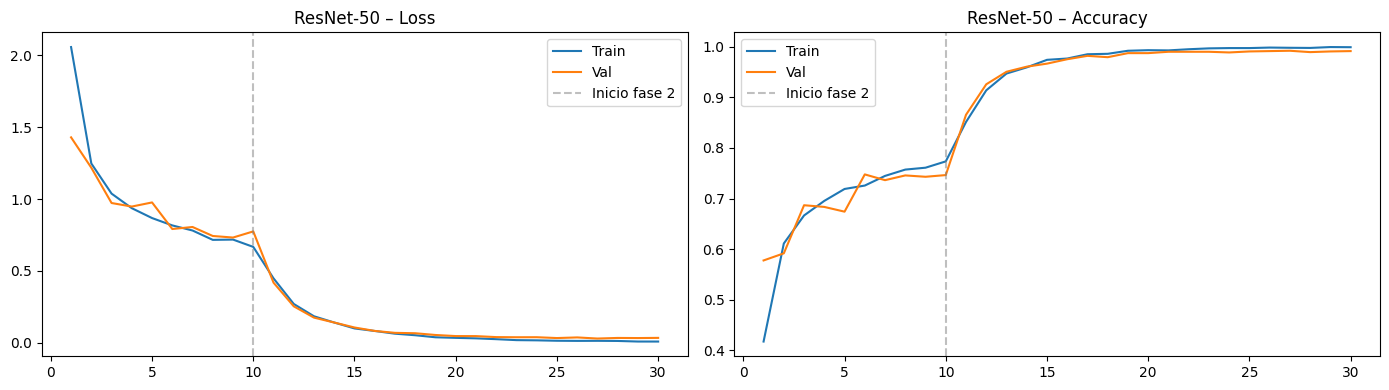

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
eps = range(1, len(history['train_loss']) + 1)
ax1.plot(eps, history['train_loss'], label='Train'); ax1.plot(eps, history['val_loss'], label='Val')
ax1.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Inicio fase 2')
ax1.set_title('ResNet-50 – Loss'); ax1.legend()
ax2.plot(eps, history['train_acc'],  label='Train'); ax2.plot(eps, history['val_acc'],  label='Val')
ax2.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Inicio fase 2')
ax2.set_title('ResNet-50 – Accuracy'); ax2.legend()
plt.tight_layout(); plt.savefig('resnet50_curves.png', dpi=120); plt.show()

## 10. Evaluación en test set

In [2]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy()); all_labels.extend(labels.numpy())

acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Test Accuracy ResNet-50: {acc:.4f}')
print(classification_report(all_labels, all_preds, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax)
ax.set_title('Matriz de confusión – ResNet-50')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout(); plt.savefig('resnet50_confusion.png', dpi=120); plt.show()

# Guardar predicciones para el ensamble
np.save('preds_resnet50.npy', np.array(all_preds))
np.save('labels_test.npy',    np.array(all_labels))
print('Predicciones guardadas en preds_resnet50.npy')

NameError: name 'model' is not defined

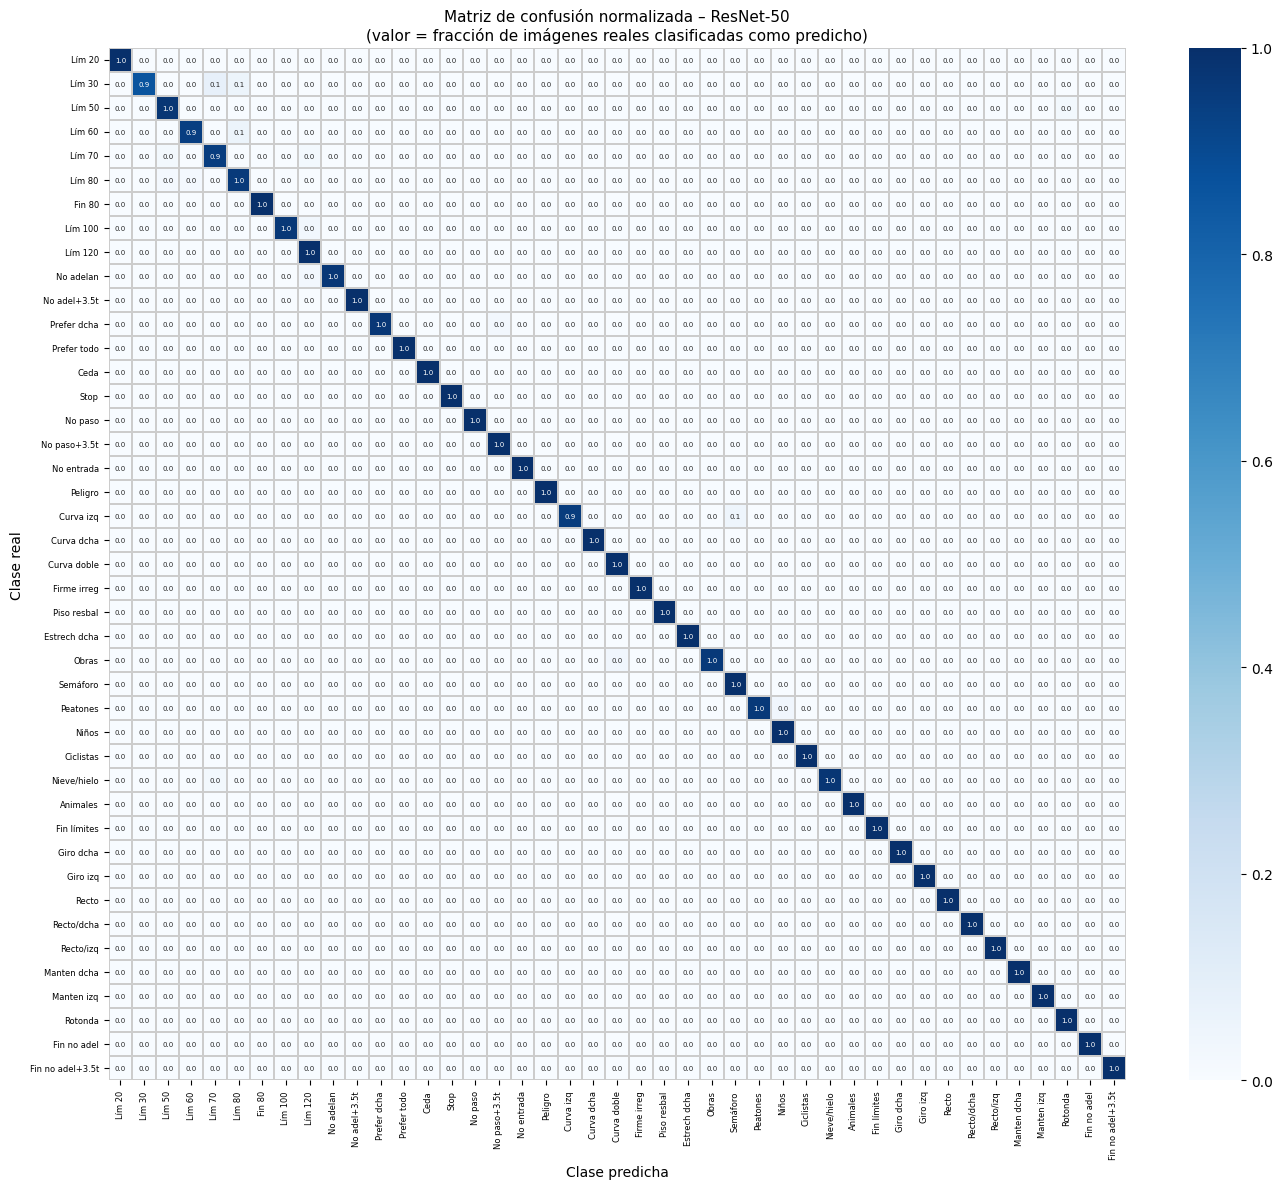

La diagonal principal muestra el accuracy por clase (1.0 = perfecto).


In [17]:
# Nombres cortos de las 43 clases GTSRB
CLASS_NAMES = [
    'Lím 20',  'Lím 30',  'Lím 50',  'Lím 60',  'Lím 70',
    'Lím 80',  'Fin 80',  'Lím 100', 'Lím 120', 'No adelan',
    'No adel+3.5t', 'Prefer dcha', 'Prefer todo', 'Ceda',  'Stop',
    'No paso',  'No paso+3.5t', 'No entrada', 'Peligro', 'Curva izq',
    'Curva dcha', 'Curva doble', 'Firme irreg', 'Piso resbal', 'Estrech dcha',
    'Obras',   'Semáforo',  'Peatones', 'Niños',   'Ciclistas',
    'Nieve/hielo', 'Animales', 'Fin límites', 'Giro dcha', 'Giro izq',
    'Recto',   'Recto/dcha', 'Recto/izq', 'Manten dcha', 'Manten izq',
    'Rotonda',  'Fin no adel', 'Fin no adel+3.5t'
]

cm = confusion_matrix(all_labels, all_preds)

# Normalizar por fila (porcentaje de acierto por clase real)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=True,           # muestra el valor en cada celda
    fmt='.1f',            # 1 decimal (ej. 0.9)
    cmap='Blues',
    linewidths=0.3,
    linecolor='#cccccc',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    vmin=0, vmax=1,
    ax=ax,
    annot_kws={'size': 5}  # fuente pequeña para que quepan los números
)
ax.set_title('Matriz de confusión normalizada – ResNet-50\n(valor = fracción de imágenes reales clasificadas como predicho)', fontsize=11)
ax.set_xlabel('Clase predicha', fontsize=10)
ax.set_ylabel('Clase real',     fontsize=10)
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6, rotation=0)
plt.tight_layout()
plt.savefig('resnet50_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('La diagonal principal muestra el accuracy por clase (1.0 = perfecto).')

In [1]:
# Dataset de test SIN normalización (para visualizar la imagen original)
class RawSubset(Dataset):
    def __init__(self, subset):
        self.subset = subset
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]   # img es tensor [3,224,224] del raw_transform
        return img, label

raw_test_ds = RawSubset(test_sub)

def predecir_aleatoria(n_imagenes=6):
    """Muestra n_imagenes aleatorias del test set con su etiqueta real y la predicción."""
    indices = random.sample(range(len(raw_test_ds)), n_imagenes)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.flatten()

    model.eval()
    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_raw, label_real = raw_test_ds[idx]

            # Imagen para mostrar (desnormalizar de raw_transform: ya es [0,1])
            img_np = img_raw.permute(1, 2, 0).numpy()  # [H,W,3]
            img_np = np.clip(img_np, 0, 1)

            # Imagen para el modelo (aplicar normalización)
            img_pil    = transforms.ToPILImage()(img_raw)
            img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)

            # Predicción
            logits     = model(img_tensor)
            probs      = torch.softmax(logits, dim=1)[0]
            pred_cls   = probs.argmax().item()
            confianza  = probs[pred_cls].item() * 100

            # Color del borde: verde si acierta, rojo si falla
            acierto = (pred_cls == label_real)
            color   = '#2E7D32' if acierto else '#C62828'

            ax.imshow(img_np)
            ax.set_title(
                f'Real:  {CLASS_NAMES[label_real]} (cls {label_real})\n'
                f'Pred:  {CLASS_NAMES[pred_cls]} (cls {pred_cls})\n'
                f'Conf:  {confianza:.1f}%  |  {"✓ Correcto" if acierto else "✗ Error"}',
                fontsize=8, color=color, fontweight='bold'
            )
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
            ax.axis('off')

    plt.suptitle('Prueba aleatoria – ResNet-50 (borde verde = correcto, rojo = error)',
                 fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig('resnet50_prueba_aleatoria.png', dpi=120, bbox_inches='tight')
    plt.show()

# Ejecutar la prueba – volver a correr esta celda para ver nuevas imágenes aleatorias
predecir_aleatoria(n_imagenes=6)

NameError: name 'Dataset' is not defined